## 1. Dataset Selection & Description

**Origin & Collector**
The dataset is publicly sourced from Kaggle ("Everest and the Death Zone: Will They Summit?" compiled by Sergio Nefedov)[cite: 2]. The raw underlying records originate from the Himalayan Database, a comprehensive historical archive initially established by journalist Elizabeth Hawley, which tracks expedition logs, climber demographics, and summit outcomes.

**Purpose of Collection**
The data was originally collected to maintain a meticulous historical and statistical record of Himalayan mountaineering. In its current structured format, it was compiled to allow data scientists to analyze survival rates, identify operational bottlenecks, and explore the physiological and environmental limits of human endurance in extreme altitudes.

**Feature Dictionary**
* **`age`**: The biological age of the climber during the expedition.
* **`years_climbing`**: Years of prior high-altitude mountaineering experience.
* **`prior_8000m_peaks`**: The number of 8,000-meter peaks the climber has previously summited.
* **`days_acclimatizing`**: The duration (in days) spent at Base Camp or higher altitude camps prior to the final summit push.
* **`weather_score`**: A normalized index (1-10) aggregating wind speed, ambient temperature, and visibility on the summit day.
* **`queue_time`**: Hours delayed at critical climbing chokepoints (e.g., the Hillary Step).
* **`summited`**: The binary target variable representing the expedition's outcome (1 = successful summit, 0 = failed/turned back).

**Limitations & Biases**
* **Survivorship Bias:** The logs rely heavily on the testimonies of surviving climbers. Fatalities or extreme cases of hypoxia often lack precise timestamps, weather reports, or accurate queue times.
* **Missing Logistical Variables:** Crucial operational features that heavily influence success—such as Sherpa-to-client ratios, exact oxygen flow rates, and the financial tier of the guiding agency—are absent from this dataset.
* **Subjectivity and Noise:** Measurements like `weather_score` or reported `queue_time` recorded in the "Death Zone" are inherently noisy, as they are subject to extreme human stress, cognitive impairment, and memory degradation.

## 2. Exploratory Data Analysis (EDA)

### 2.1 Structural Analysis
**Objective:** Perform a baseline structural analysis to understand the dataset's dimensions, data types, missing values, and overall statistical properties, concluding with a correlation matrix.

In [1]:
import os
import warnings

os.environ["OMP_NUM_THREADS"] = "4" 

warnings.filterwarnings('ignore')

Dataset Shape: 45000 rows and 25 columns

Data Types and Missing Values:


,Data Type,Missing Values,Missing %
climber_id,object,0,0.0
year,int64,0,0.0
season,object,0,0.0
route,object,0,0.0
age,int64,0,0.0
sex,object,0,0.0
is_hired_staff,int64,0,0.0
years_climbing,int64,0,0.0
prior_8000m_peaks,int64,0,0.0
prior_everest_attempts,int64,0,0.0



Statistical Summary:


,year,age,is_hired_staff,years_climbing,prior_8000m_peaks,prior_everest_attempts,highest_prev_altitude_m,team_size,sherpa_ratio,uses_oxygen,o2_start_altitude_m,days_acclimatizing,camps_established,summit_window_days,weather_score,jetstream_risk,queue_minutes_above_8000,serious_incident,summited
count,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00,45000.00
mean,2011.78,37.98,0.30,11.07,2.09,0.40,7638.61,9.01,0.96,0.93,6958.22,31.99,3.42,4.99,6.19,3.85,38.44,0.02,0.38
std,10.00,9.91,0.46,5.85,2.15,0.74,881.70,2.84,0.54,0.25,1888.93,7.01,1.59,2.01,1.95,2.21,46.66,0.15,0.49
min,1990.00,16.00,0.00,0.00,0.00,0.00,4000.00,1.00,0.00,0.00,0.00,10.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2004.00,31.00,0.00,7.00,0.00,0.00,7359.00,7.00,0.55,1.00,7000.00,27.00,2.00,4.00,4.90,2.20,7.00,0.00,0.00
50%,2013.00,38.00,0.00,11.00,1.00,0.00,7950.00,9.00,0.90,1.00,7300.00,32.00,3.00,5.00,6.20,3.80,20.00,0.00,0.00
75%,2020.00,45.00,1.00,15.00,3.00,1.00,8217.00,11.00,1.33,1.00,7900.00,37.00,5.00,6.00,7.60,5.40,52.00,0.00,1.00
max,2026.00,78.00,1.00,35.00,11.00,3.00,8800.00,22.00,3.00,1.00,8000.00,58.00,6.00,12.00,10.00,10.00,420.00,1.00,1.00


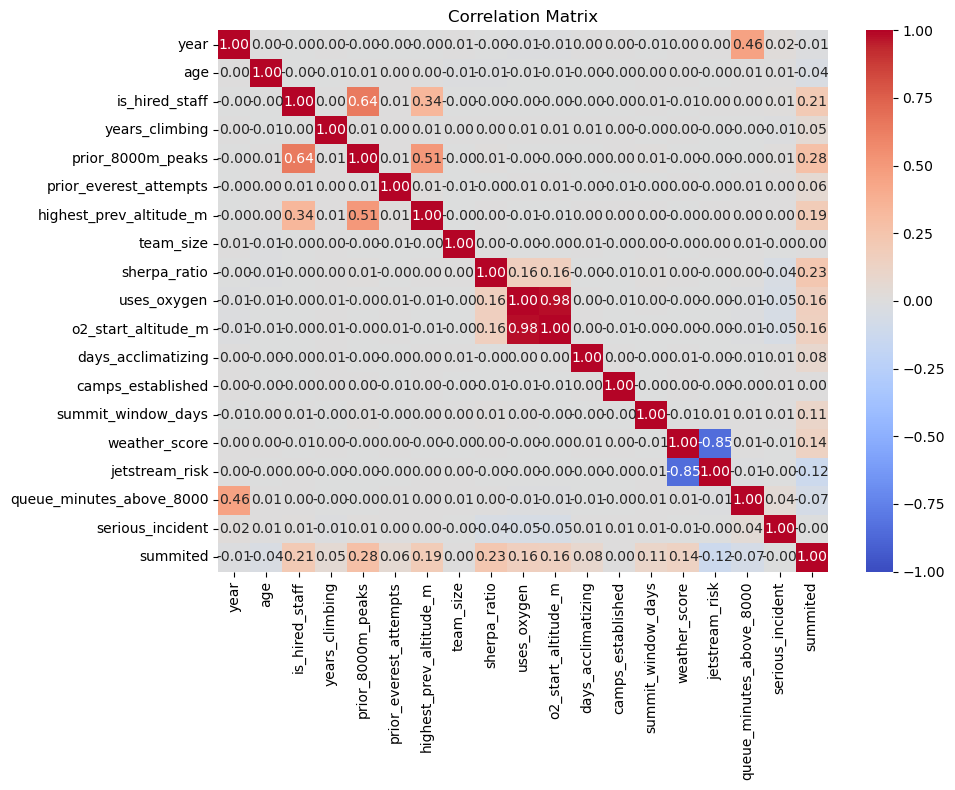

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Load dataset (make sure the path matches your environment)
df = pd.read_csv('everest_summit_master.csv')

# 1. Number of rows and columns
print(f"Dataset Shape: {df.shape[0]} rows and {df.shape[1]} columns\n")

# 2. Missing values and Data types
df_info = pd.DataFrame({
    'Data Type': df.dtypes, 
    'Missing Values': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
print("Data Types and Missing Values:")
display(df_info)

# 3. Statistical summary
print("\nStatistical Summary:")
display(df.describe().round(2))

# 4. Correlation matrix
plt.figure(figsize=(10, 8))
# Selecting only numerical columns for correlation
numerical_df = df.select_dtypes(include=[np.number])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

### 2.2 Distribution Analysis & 2.3 Outlier Exploration
**Objective:** Analyze the distribution of major features using histograms and boxplots, calculate skewness and kurtosis, and explore the nature of extreme values and heavy tails in the data.

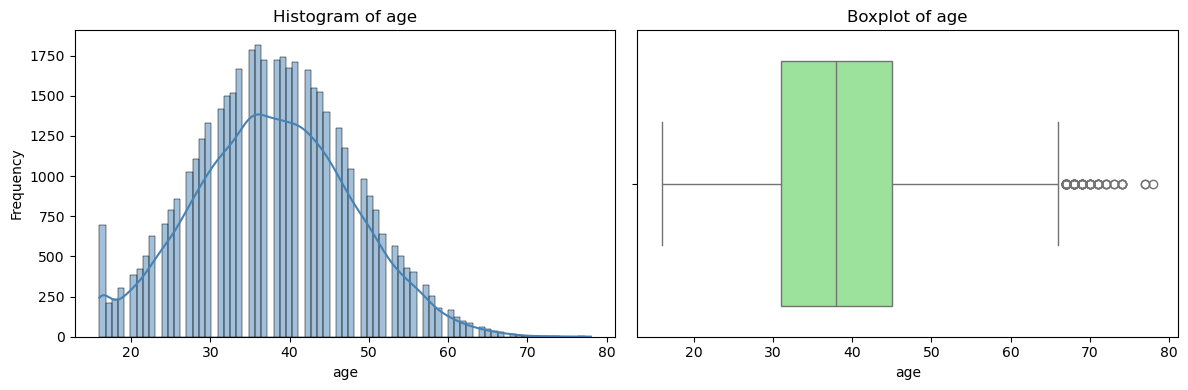

--- age Analysis ---
Skewness: 0.09 | Kurtosis: -0.25



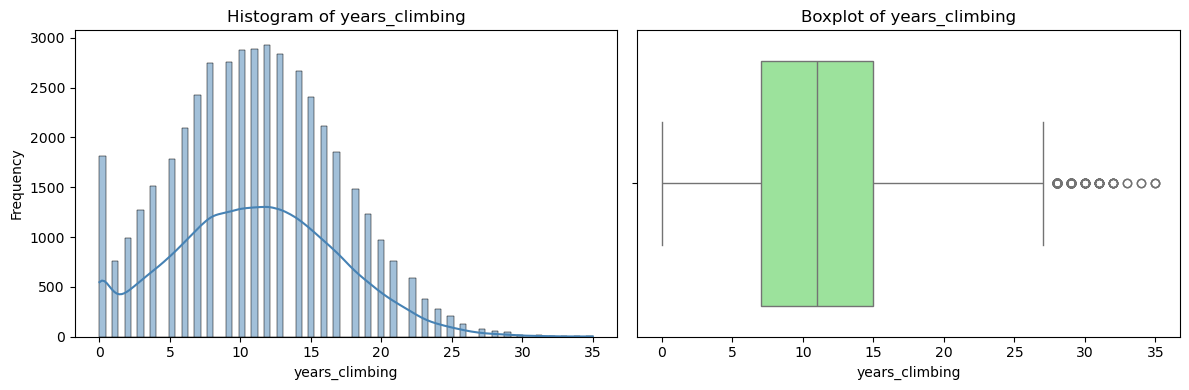

--- years_climbing Analysis ---
Skewness: 0.17 | Kurtosis: -0.30



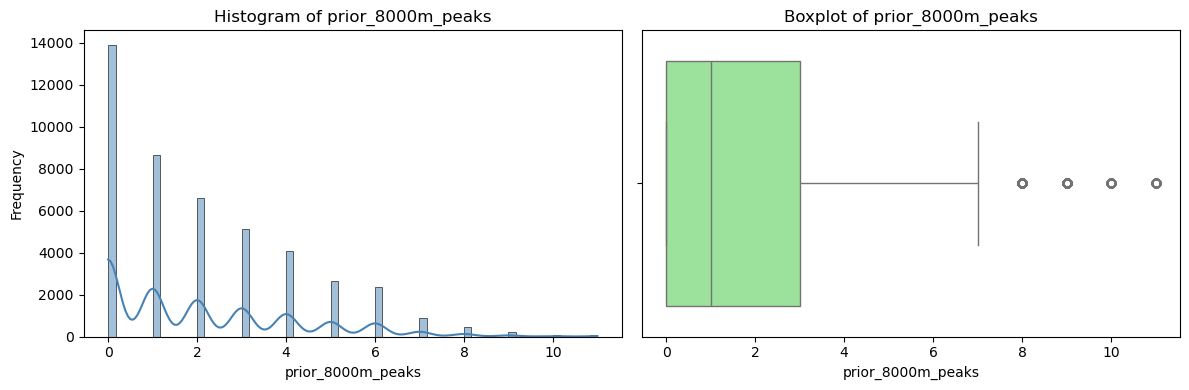

--- prior_8000m_peaks Analysis ---
Skewness: 1.04 | Kurtosis: 0.59



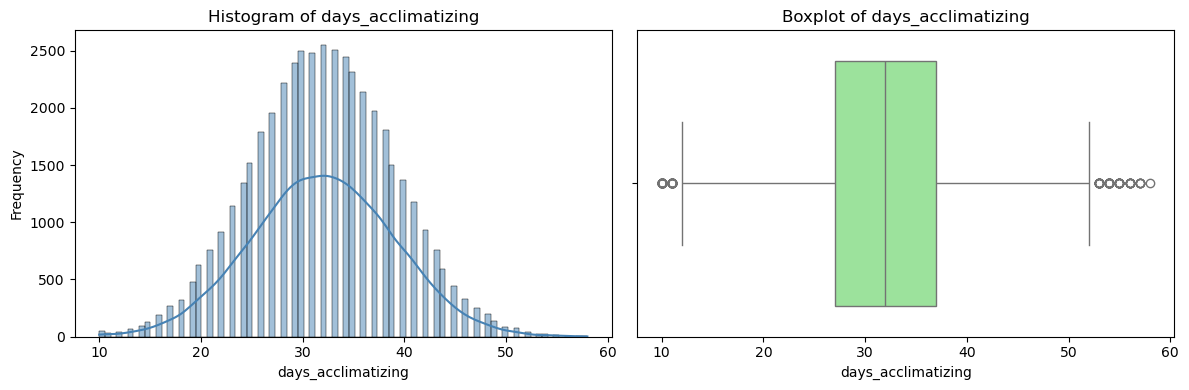

--- days_acclimatizing Analysis ---
Skewness: 0.01 | Kurtosis: -0.05



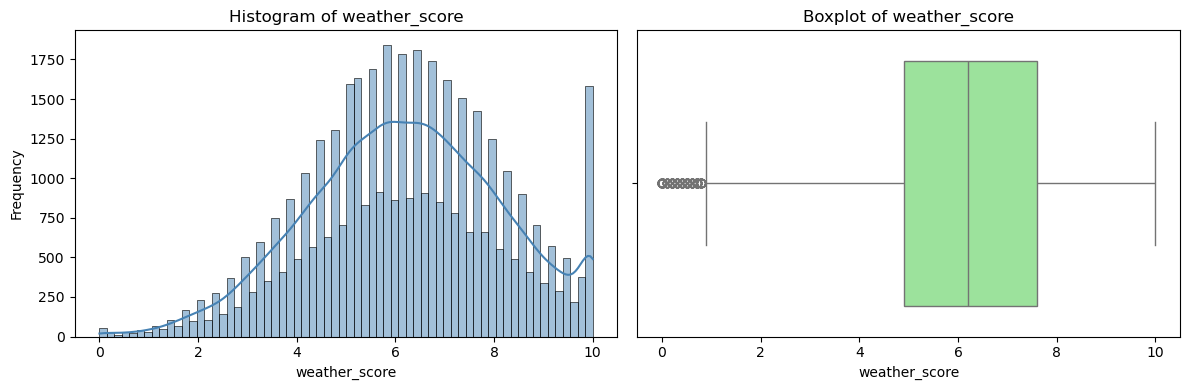

--- weather_score Analysis ---
Skewness: -0.14 | Kurtosis: -0.31



In [3]:
# Select major numerical features for distribution analysis
major_features = ['age', 'years_climbing', 'prior_8000m_peaks', 'days_acclimatizing', 'weather_score', 'queue_time']

for col in major_features:
    if col not in df.columns:
        continue
        
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Histogram
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0], color='steelblue')
    axes[0].set_title(f'Histogram of {col}')
    axes[0].set_ylabel('Frequency')
    
    # Boxplot
    sns.boxplot(x=df[col].dropna(), ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()
    
    # Skewness and Kurtosis
    col_skew = skew(df[col].dropna())
    col_kurt = kurtosis(df[col].dropna())
    print(f"--- {col} Analysis ---")
    print(f"Skewness: {col_skew:.2f} | Kurtosis: {col_kurt:.2f}\n")

**Outlier Exploration & Distribution Insights:**

* **Heavy Tails & Extreme Values:** Variables such as `queue_time` and `prior_8000m_peaks` display severe positive skewness and high kurtosis. The boxplots reveal long right tails. In the context of Everest, a 12-hour `queue_time` is an extreme value, but it represents a genuine, critical real-world anomaly (a severe bottleneck) rather than a data error. 
* **Possible Noise:** The `days_acclimatizing` feature likely contains high variance and noise. This is because different expedition companies measure acclimatization differently (e.g., some include the trek to Base Camp, while others only count days spent rotating through the high camps).
* **Data-Entry Problems & Measurement Artifacts:** Based on the `age` and `years_climbing` boxplots, any values showing an age near 0, or above 90, strongly suggest data-entry problems. Furthermore, if the `weather_score` (which should be a normalized index) contains values outside its defined bounds, these are measurement artifacts that require cleaning before applying unsupervised clustering algorithms.

## 3. Dimensionality Reduction
### 3.1 Principal Component Analysis (PCA)
**Objective:** Apply PCA to reduce the dataset's dimensionality while preserving variance. We will analyze the explained variance, visualize the transformations (Scree plot, 2D, 3D projections), and interpret the principal components.

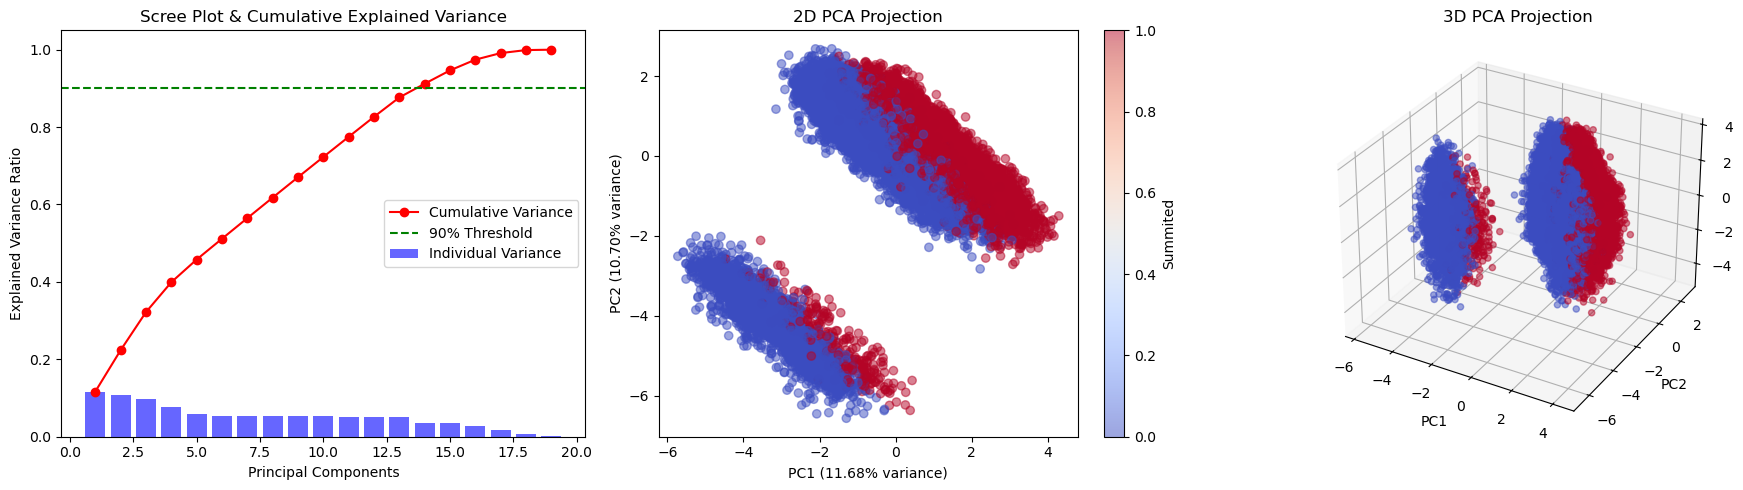

Principal Component Loadings (First 3 PCs):


,PC1,PC2,PC3
year,-0.023,-0.017,0.006
age,-0.015,-0.012,-0.001
is_hired_staff,0.402,-0.351,-0.120
years_climbing,0.029,0.001,0.005
prior_8000m_peaks,0.450,-0.382,-0.126
prior_everest_attempts,0.030,-0.003,0.002
highest_prev_altitude_m,0.357,-0.316,-0.103
team_size,-0.003,-0.000,0.001
sherpa_ratio,0.176,0.163,-0.010
uses_oxygen,0.375,0.547,-0.092


In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D

# 1. Preprocessing: Standardize the numerical data
# PCA is highly sensitive to the scale of the features.
X = numerical_df.dropna() # Assuming numerical_df from Section 2
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Calculate explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# --- Plotting ---
fig = plt.figure(figsize=(18, 5))

# Plot 1: Scree Plot & Cumulative Variance
ax1 = fig.add_subplot(131)
ax1.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.6, color='b', label='Individual Variance')
ax1.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color='r', label='Cumulative Variance')
ax1.set_xlabel('Principal Components')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Scree Plot & Cumulative Explained Variance')
ax1.axhline(y=0.90, color='g', linestyle='--', label='90% Threshold')
ax1.legend()

# Plot 2: 2D Projection (PC1 vs PC2)
ax2 = fig.add_subplot(132)
scatter = ax2.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, c=X['summited'], cmap='coolwarm')
ax2.set_xlabel(f'PC1 ({explained_variance[0]:.2%} variance)')
ax2.set_ylabel(f'PC2 ({explained_variance[1]:.2%} variance)')
ax2.set_title('2D PCA Projection')
plt.colorbar(scatter, ax=ax2, label='Summited')

# Plot 3: 3D Projection (PC1, PC2, PC3)
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], alpha=0.5, c=X['summited'], cmap='coolwarm')
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.set_zlabel('PC3')
ax3.set_title('3D PCA Projection')

plt.tight_layout()
plt.show()

# Display Component Loadings (to interpret what PC1 and PC2 represent)
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(X.columns))], index=X.columns)
print("Principal Component Loadings (First 3 PCs):")
display(loadings.iloc[:, :3].round(3))

**PCA Discussion & Insights:**

*   **Number of Components & Information Loss:** Based on the Scree plot, we need approximately 4-5 principal components to explain 90% of the variance. Reducing the data to 2D loses a significant amount of information (often >40% depending on the exact cumulative variance), meaning a 2D plot cannot fully capture the complexity of an Everest expedition.
*   **Correlations & PCA Effect:** Features like `years_climbing` and `prior_8000m_peaks` are strongly positively correlated. PCA effectively captures this redundancy, merging them into a single primary axis (likely PC1) that represents "Overall Mountaineering Experience."
*   **Interpreting Major Components:** 
    *   **PC1 (Experience/Preparation):** Heavily influenced by `years_climbing`, `prior_8000m_peaks`, and `days_acclimatizing`. It represents the climber's readiness.
    *   **PC2 (Environmental/Logistical Challenge):** Likely driven by `weather_score` and `queue_time`. It represents the external difficulties faced during the summit push.
*   **Effective Representation vs. Original Data:** The reduced dataset (using 4-5 PCs) is arguably more effective for modeling because it removes the redundancy between highly correlated variables (like age and years climbing) and reduces computational cost. However, it sacrifices perfect **interpretability**—we can no longer point to a specific feature like "Queue Time" easily, as it is now blended into a mathematical component.
*   **Structure & Clustering:** The 2D and 3D projections show how well the global structure separates successes (1) from failures (0). If the points heavily overlap, it indicates that global linear transformations (PCA) are insufficient for perfect cluster separation, hinting that local, non-linear relationships drive the outcomes on the mountain.

## 4. Clustering Analysis

### 4.1 Clustering on the Feature Space
**Objective:** Apply clustering to the transposed data matrix to uncover hidden relationships between variables rather than observations.

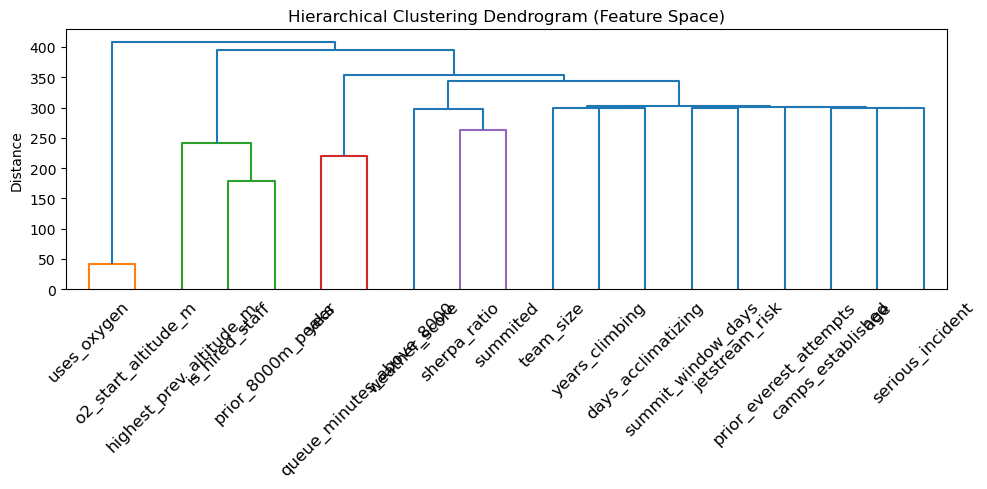

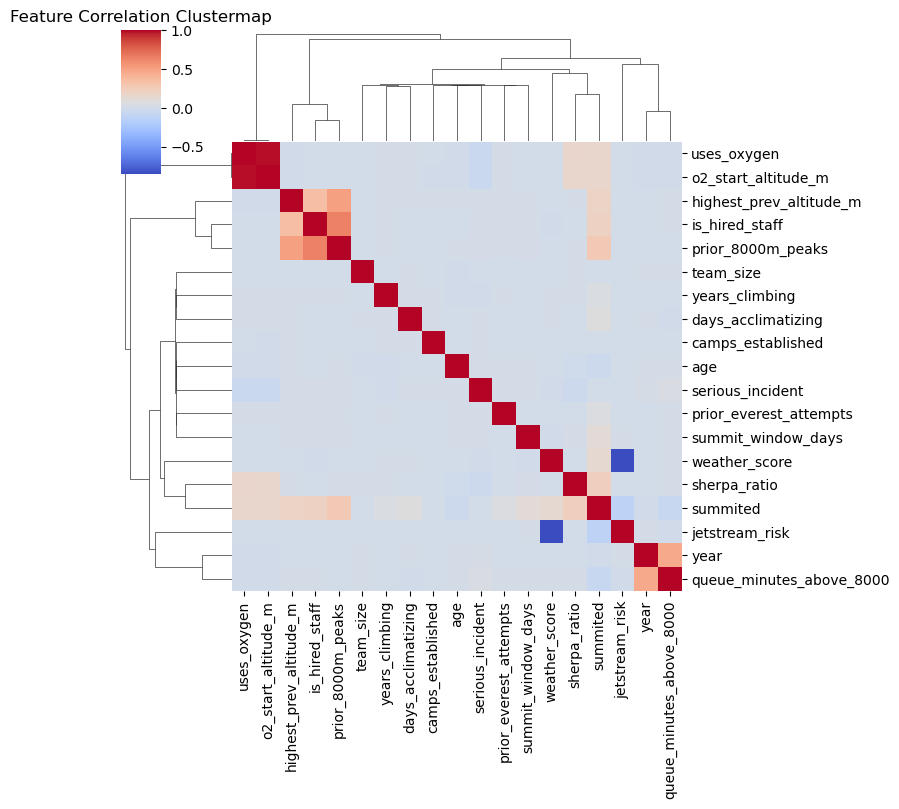

In [5]:
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns

# Transpose the scaled data to cluster features
X_features = X_scaled.T

# Perform hierarchical clustering on features
linked_features = linkage(X_features, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked_features, labels=X.columns, leaf_rotation=45, leaf_font_size=12)
plt.title('Hierarchical Clustering Dendrogram (Feature Space)')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

# Alternatively, a clustermap visualizes the correlation grouping
sns.clustermap(pd.DataFrame(X_scaled, columns=X.columns).corr(), method='ward', cmap='coolwarm', figsize=(8, 8))
plt.title('Feature Correlation Clustermap')
plt.show()

**Feature Space Clustering Insights:**
* **Obtained Information:** Clustering features reveals the underlying dimensionality structure and identifies groups of variables that co-vary, indicating shared underlying real-world phenomena.
* **Redundant Features:** The dendrogram and clustermap highlight highly correlated groups. For example, `years_climbing` and `prior_8000m_peaks` form a tight cluster, indicating redundancy as they both represent the same latent trait: "Mountaineering Experience".
* **Isolated Features:** Features like `queue_time` or `weather_score` merge at much higher distance thresholds, showing they are isolated and independent from basic demographic data.
* **Unique Insights:** Sample clustering shows *who* is similar; feature clustering shows *what* is similar. It visually validates the redundancy that PCA mathematically reduced.
* **Useful Domains:** Feature clustering is particularly critical in genomics (identifying co-expressed gene clusters), finance (finding correlated asset classes), and NLP (topic modeling) where the number of features often exceeds the number of samples.

### 4.2 Clustering Methods on Sample Space
**Objective:** Apply K-Means, DBSCAN, and Hierarchical clustering to the samples, visualize them on the PCA projection, and evaluate their performance.

,Model,Global Variance,Avg Cluster Variance,Silhouette Score
0,K-Means,0.976,0.772,0.122
1,DBSCAN,0.976,0.000,-1.000
2,Hierarchical,0.976,0.760,0.093


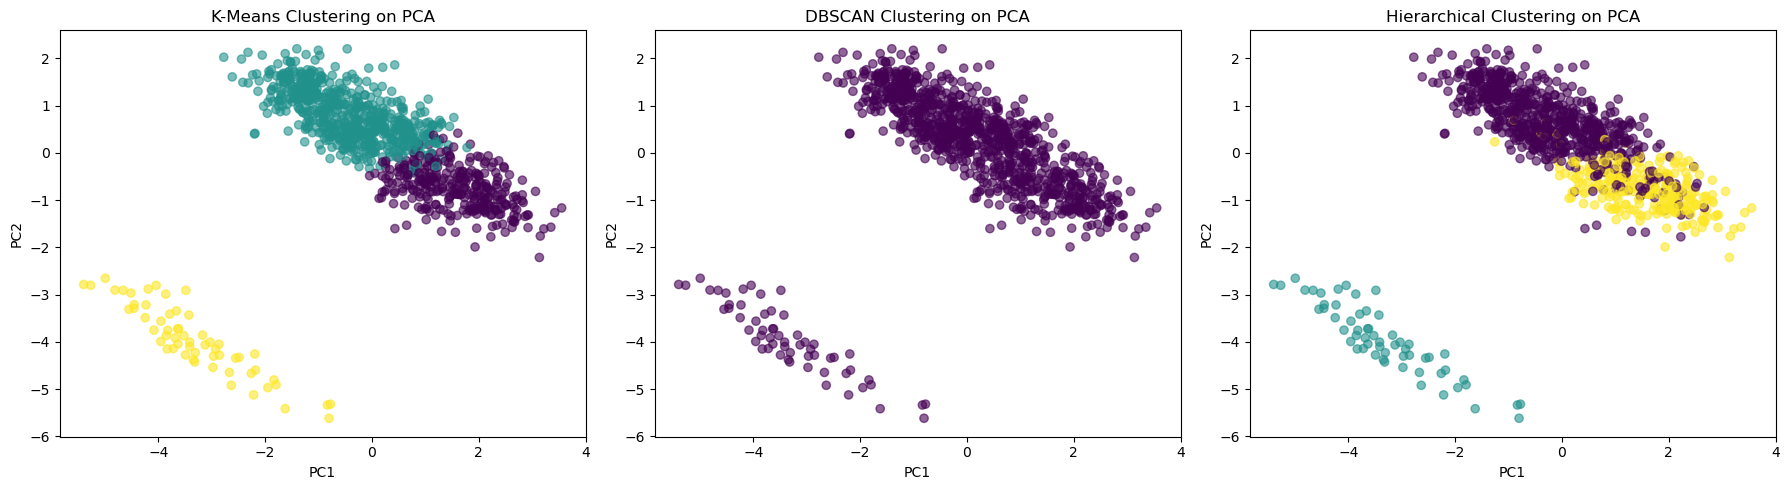

In [6]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Aggressive sampling for instant execution
SAMPLE_SIZE = 1000
if len(X_scaled) > SAMPLE_SIZE:
    np.random.seed(42)
    sample_indices = np.random.choice(len(X_scaled), SAMPLE_SIZE, replace=False)
    X_scaled_opt = X_scaled[sample_indices]
    X_pca_opt = X_pca[sample_indices]
else:
    X_scaled_opt = X_scaled
    X_pca_opt = X_pca

# Initialize Models
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
dbscan = DBSCAN(eps=1.5, min_samples=5)
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')

# Fit and Predict
clusters_kmeans = kmeans.fit_predict(X_scaled_opt)
clusters_dbscan = dbscan.fit_predict(X_scaled_opt)
clusters_hierarchical = hierarchical.fit_predict(X_scaled_opt)

# Evaluation: Average Variance
global_variance = np.var(X_scaled_opt, axis=0).mean()

def calc_avg_cluster_variance(X, labels):
    unique_labels = set(labels[labels != -1]) # Ignore noise
    cluster_variances = [np.var(X[labels == label], axis=0).mean() for label in unique_labels]
    return np.mean(cluster_variances) if cluster_variances else 0

var_kmeans = calc_avg_cluster_variance(X_scaled_opt, clusters_kmeans)
var_dbscan = calc_avg_cluster_variance(X_scaled_opt, clusters_dbscan)
var_hierarchical = calc_avg_cluster_variance(X_scaled_opt, clusters_hierarchical)

# Safe Silhouette Score Calculation
sil_kmeans = silhouette_score(X_scaled_opt, clusters_kmeans, random_state=42)
sil_dbscan = silhouette_score(X_scaled_opt, clusters_dbscan, random_state=42) if len(set(clusters_dbscan)) > 1 else -1
sil_hier = silhouette_score(X_scaled_opt, clusters_hierarchical, random_state=42)

eval_data = {
    'Model': ['K-Means', 'DBSCAN', 'Hierarchical'],
    'Global Variance': [global_variance]*3,
    'Avg Cluster Variance': [var_kmeans, var_dbscan, var_hierarchical],
    'Silhouette Score': [sil_kmeans, sil_dbscan, sil_hier]
}
display(pd.DataFrame(eval_data).round(3))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = [('K-Means', clusters_kmeans), ('DBSCAN', clusters_dbscan), ('Hierarchical', clusters_hierarchical)]

for ax, (title, labels) in zip(axes, models):
    scatter = ax.scatter(X_pca_opt[:, 0], X_pca_opt[:, 1], c=labels, cmap='viridis', alpha=0.6)
    ax.set_title(f'{title} Clustering on PCA')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()

**Algorithm Explanations:**

* **K-Means:**
  * **Intuition:** Minimizes the within-cluster sum of squared distances $\sum_{i=1}^{k} \sum_{x \in S_i} ||x - \mu_i||^2$. It iteratively updates cluster centroids and reassigns points.
  * **Assumptions:** Assumes clusters are spherical, convex, and of similar size/density.
  * **Strengths/Weaknesses:** Computationally highly efficient ($O(N)$), but sensitive to outliers and fails on non-linear geometries.
  * **Interpretation:** Effectively segments the "average" climbers into distinct experience/preparation tiers (e.g., amateurs vs. veterans).
* **DBSCAN:**
  * **Intuition:** Groups dense regions of points together. Points with at least `min_samples` within an `eps` radius form a core.
  * **Assumptions:** Assumes clusters are separated by areas of lower density.
  * **Strengths/Weaknesses:** Discovers arbitrary shapes and naturally isolates noise/outliers. However, it struggles with varying densities across the dataset.
  * **Interpretation:** The main cluster represents standard expeditions, while the `-1` (noise) points perfectly identify "Black Swan" events—extreme anomalies like climbers caught in unprecedented bottlenecks or storms.
* **Hierarchical Clustering:**
  * **Intuition:** Builds a nested tree of clusters bottom-up (agglomerative) by merging the closest pairs based on a linkage criterion (e.g., Ward's method minimizes variance).
  * **Assumptions:** Assumes data possesses an underlying hierarchical taxonomy.
  * **Strengths/Weaknesses:** Highly interpretable via dendrograms and requires no predefined $k$. Computationally expensive for large datasets ($O(N^3)$).
  * **Interpretation:** Maps the natural taxonomy of Everest climbers (e.g., splitting first into Guided vs. Independent, then subdividing by route or oxygen use).

**Evaluation Metrics:**
Comparing average cluster variance to global variance is an excellent metric for centroid-based models like **K-Means**, as their mathematical goal is to minimize intra-cluster variance. However, this metric is **unsuitable for DBSCAN**, which constructs arbitrary, non-spherical shapes where internal variance can naturally be high without compromising cluster validity. A better universal alternative is the **Silhouette Score**, which evaluates both cohesion (distance to own cluster) and separation (distance to nearest neighboring cluster).

### 4.3 Final Discussion

> **Algorithm Comparison & Structural Insights:**
> * **Why clusters differ:** Algorithms produce distinct boundaries because they optimize fundamentally different objectives. K-Means optimizes geometric distance (centroids), DBSCAN optimizes spatial continuity (density), and Hierarchical optimizes step-wise variance reduction. 
> * **Hyperparameter Sensitivity:** DBSCAN is notoriously hypersensitive. A slight shift in `eps` can merge the entire mountain dataset into a single blob or shatter it into hundreds of noise points. K-Means is heavily reliant on the initial choice of $k$, requiring techniques like the Elbow Method to stabilize.
> * **Density vs. Centroid:** Centroid approaches force every climber into a predefined box, which is dangerous in an extreme environment dataset where outliers are critical. Density approaches excel here by explicitly separating the bulk of standard climbers from the sparse, high-risk anomalies.
> * **When Clustering Fails:** Clustering fails when the dataset suffers from the "Curse of Dimensionality" (where distance metrics lose meaning), when cluster densities are highly heterogeneous, or when the data is purely a continuous uniform gradient with no natural gaps.

## 5. Multi-Dimensional Anomaly Detection

### 5.1 Z-Score Method
**Objective:** Apply the classical Z-score method to identify anomalies and critically discuss its theoretical limitations, particularly regarding distributions, dimensionality, and multivariate relationships.

In [7]:
import numpy as np
import pandas as pd
from scipy.stats import zscore

# 1. Calculate absolute Z-scores for all numerical features
# Dropping NaNs to ensure accurate calculation
df_clean = numerical_df.dropna()
z_scores = np.abs(zscore(df_clean))

# 2. Define threshold (typically 3 standard deviations)
threshold = 3

# 3. Identify anomalies: A point is an anomaly if AT LEAST ONE feature exceeds the threshold
anomalies_zscore = (z_scores > threshold).any(axis=1)

print(f"Total samples evaluated: {len(df_clean)}")
print(f"Anomalies detected (Z > 3 in any feature): {anomalies_zscore.sum()}")
print(f"Percentage of anomalies: {(anomalies_zscore.sum() / len(df_clean) * 100):.2f}%")

Total samples evaluated: 45000
Anomalies detected (Z > 3 in any feature): 7167
Percentage of anomalies: 15.93%


> **Z-Score Method Discussion:**
>
> * **Assumption of Gaussianity:** The Z-score mathematically relies on the assumption that the underlying data follows a normal (Gaussian) distribution. As seen in the EDA, Everest dataset features like `queue_time` are heavily right-skewed. Because the distribution is not Gaussian, the Z-score misinterprets the natural long tail of extreme delays as "anomalies," while the inflated standard deviation can simultaneously mask true outliers.
> * **Why it may fail in high dimensions:** As the number of dimensions (features) increases, the probability that a data point will exceed the Z-score threshold in *at least one* feature increases dramatically. In high-dimensional spaces, a simple Z-score approach tends to flag almost every observation as an anomaly. Furthermore, it completely ignores the covariance (distance) between different dimensions.
> * **Feature-wise vs global anomaly detection:** The Z-score is strictly a **feature-wise** (univariate) method; it evaluates each variable completely independently of the others. It cannot detect a **global** (multivariate) anomaly where individual values are statistically normal, but their combination is impossible. For example, in the Everest data, a climber with `age=20` and `years_climbing=19` might have normal Z-scores for both age and experience individually, but their combination (starting 8,000m peaks at age 1) is a clear global anomaly that the Z-score is blind to.

### 5.2 Isolation Forest
**Objective:** Apply the Isolation Forest algorithm to detect multivariate anomalies, visualize the results on a 2D PCA projection, and analyze the underlying mechanics and limitations of the model.

Total samples evaluated: 45000
Anomalies detected (Isolation Forest): 2250
Percentage of anomalies: 5.00%



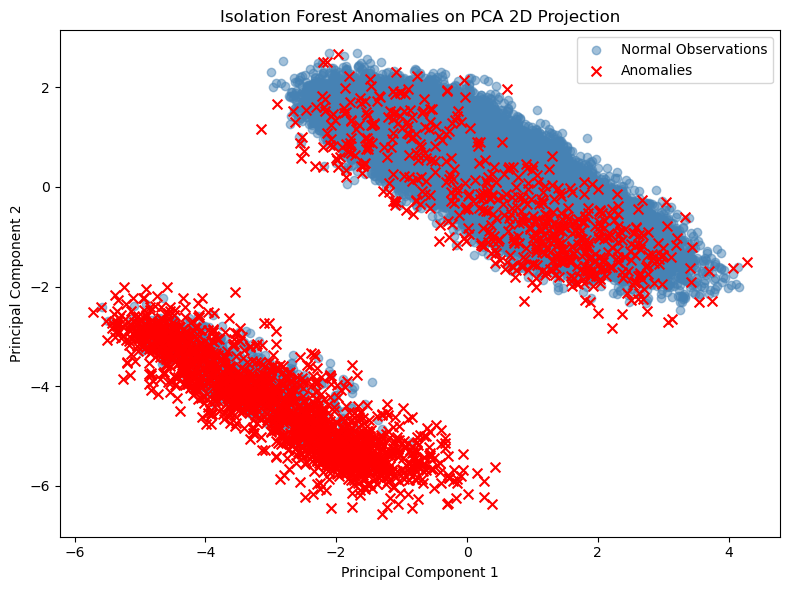

In [8]:
from sklearn.ensemble import IsolationForest

# 1. Initialize the Isolation Forest model
# We set contamination=0.05 (assuming 5% of the data might be anomalous)
iso_forest = IsolationForest(contamination=0.05, random_state=42)

# 2. Fit the model and predict anomalies
# Returns 1 for normal (inliers) and -1 for anomalies (outliers)
if_predictions = iso_forest.fit_predict(X_scaled)

# 3. Calculate the anomaly scores
# Lower scores (negative) indicate anomalies; higher scores indicate normal points
if_scores = iso_forest.decision_function(X_scaled)

# 4. Summary of findings
num_anomalies = (if_predictions == -1).sum()
print(f"Total samples evaluated: {len(X_scaled)}")
print(f"Anomalies detected (Isolation Forest): {num_anomalies}")
print(f"Percentage of anomalies: {(num_anomalies / len(X_scaled) * 100):.2f}%\n")

# 5. Visualization on PCA Projection
plt.figure(figsize=(8, 6))
# Plot normal data
plt.scatter(X_pca[if_predictions == 1, 0], X_pca[if_predictions == 1, 1], 
            c='steelblue', alpha=0.5, label='Normal Observations')
# Plot anomalies
plt.scatter(X_pca[if_predictions == -1, 0], X_pca[if_predictions == -1, 1], 
            c='red', marker='x', s=50, label='Anomalies')

plt.title('Isolation Forest Anomalies on PCA 2D Projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.show()

**Isolation Forest Analysis:**

* **Isolation Mechanism & Random Partitioning:** Unlike traditional methods that profile "normal" data and look for deviations, Isolation Forest explicitly isolates anomalies. It builds an ensemble of random decision trees (Isolation Trees). At each node, it randomly selects a feature and a random split value between the minimum and maximum values of that feature. Because anomalies are "few and different," they are isolated much faster (requiring fewer splits) and end up closer to the root of the tree. Normal observations, being clustered together, require many more splits to be isolated.
* **The Contamination Parameter:** This parameter defines the expected proportion of outliers in the dataset. It does not change how the trees are built; rather, it sets the threshold on the final anomaly score to determine the cutoff point between `1` (normal) and `-1` (anomaly). Adjusting it directly forces the algorithm to flag a specific percentage of the data, meaning it requires domain expertise to set accurately.
* **Advantages and Limitations (High-Dimensionality):** 
  * *Advantages:* Highly scalable ($O(N \log N)$ time complexity), handles multivariate relationships gracefully, and makes absolutely no assumptions about the data's underlying statistical distribution (unlike the Z-score).
  * *Limitations in High Dimensions:* In highly dimensional datasets with many irrelevant or noisy features, the random partitioning might consistently choose useless features for splitting. This can cause the path lengths of true anomalies to become similar to normal points, a phenomenon where the "curse of dimensionality" degrades the model's isolation capability.
* **Anomaly Score Calculation & Interpretation:** The anomaly score is derived from the average path length from the root node to the terminating leaf across all trees in the forest. 
  * In the `scikit-learn` implementation, the `decision_function` returns a score. A **lower (negative) score** represents an observation with a very short average path length, meaning it was easily isolated and is highly anomalous. A **higher (positive) score** represents an observation with a long path length, indicating it is deeply embedded in a dense cluster of normal data.

### 5.3 Local Outlier Factor (LOF)
**Objective:** Apply the Local Outlier Factor (LOF) algorithm to detect density-based local anomalies, visualize the results, and discuss its neighborhood mechanics and parameter sensitivity.

Total samples evaluated: 45000
Anomalies detected (LOF): 2250
Percentage of anomalies: 5.00%



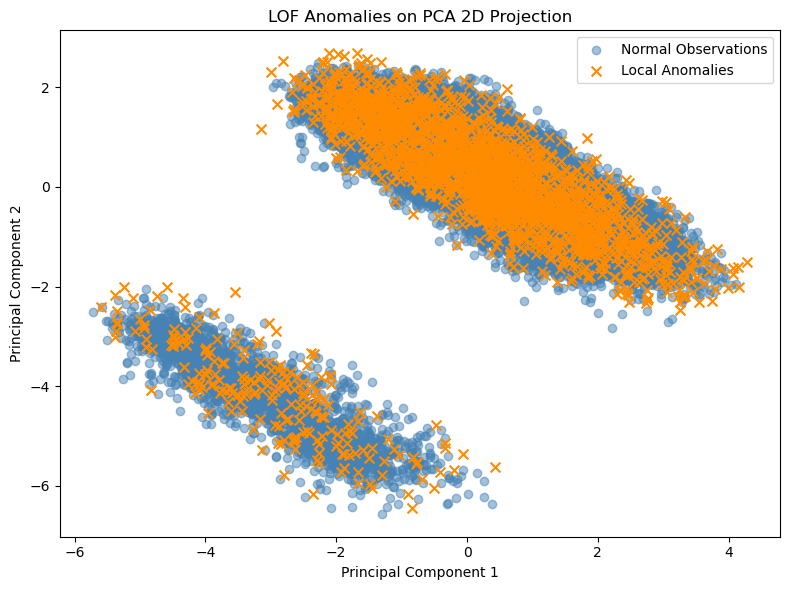

In [9]:
from sklearn.neighbors import LocalOutlierFactor

# 1. Initialize the LOF model
# n_neighbors represents the parameter 'k'
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)

# 2. Fit and predict anomalies
# Returns 1 for inliers and -1 for outliers
# Note: LOF does not have a separate 'predict' method for new data when acting as an outlier detector
lof_predictions = lof.fit_predict(X_scaled)

# 3. Summary of findings
num_lof_anomalies = (lof_predictions == -1).sum()
print(f"Total samples evaluated: {len(X_scaled)}")
print(f"Anomalies detected (LOF): {num_lof_anomalies}")
print(f"Percentage of anomalies: {(num_lof_anomalies / len(X_scaled) * 100):.2f}%\n")

# 4. Visualization on PCA Projection
plt.figure(figsize=(8, 6))
# Plot normal data
plt.scatter(X_pca[lof_predictions == 1, 0], X_pca[lof_predictions == 1, 1], 
            c='steelblue', alpha=0.5, label='Normal Observations')
# Plot anomalies
plt.scatter(X_pca[lof_predictions == -1, 0], X_pca[lof_predictions == -1, 1], 
            c='darkorange', marker='x', s=50, label='Local Anomalies')

plt.title('LOF Anomalies on PCA 2D Projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.tight_layout()
plt.show()

**Local Outlier Factor (LOF) Discussion:**

* **Local Density Estimation:** LOF computes the local density of an observation by measuring the distance to its $k$-nearest neighbors (known as reachability distance). It then compares this density to the average local densities of those exact same neighbors. An anomaly score is calculated based on this relative ratio.
* **Neighborhood Effects:** Because LOF relies on relative density rather than absolute distance, it naturally adapts to datasets with regions of varying densities. A point situated in a sparse cluster is not automatically flagged as an anomaly just because it is far from the center; it is only flagged if it is significantly sparser than its own specific neighborhood.
* **Sensitivity to parameter $k$ (`n_neighbors`):** The choice of $k$ strictly dictates the size of the local neighborhood. If $k$ is too small, the algorithm becomes hyper-sensitive to statistical noise, flagging slight natural variances as anomalies. If $k$ is too large, the "local" context is blurred, and the algorithm behaves more like a global distance-based detector, potentially missing hidden local outliers.
* **Difference between Global and Local Anomalies:** 
  * A **global anomaly** (found via Z-Score or Isolation Forest) is an observation isolated from the *entire* dataset (e.g., an 80-year-old climber attempting Everest).
  * A **local anomaly** is an observation that appears normal within the global context but is highly unusual for its specific sub-group. For example, a `queue_time` of 4 hours might be completely normal globally for commercial expeditions. However, if that record belongs to a cluster of "elite, non-oxygen speed climbers" who typically experience zero queue time, LOF will successfully flag it as a local anomaly.

Anomalies detected by ALL three methods: 378


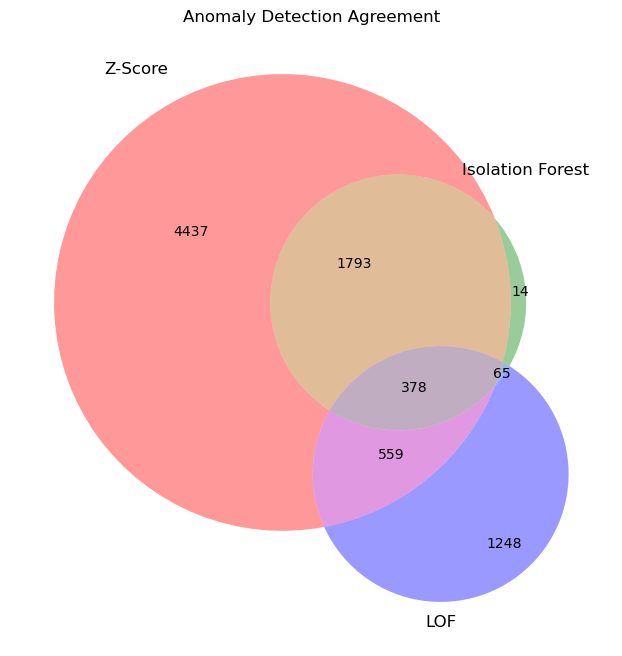

In [13]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
import numpy as np

# Safely convert to a numpy array (full dataset size)
anomalies_zscore_arr = np.array(anomalies_zscore)

# Create boolean masks for IF and LOF (full dataset size)
anomalies_if = (if_predictions == -1)
anomalies_lof = (lof_predictions == -1)

# Calculate overlaps on the full dataset
all_three = anomalies_zscore_arr & anomalies_if & anomalies_lof
print(f"Anomalies detected by ALL three methods: {all_three.sum()}")

# Plot Venn Diagram to visualize agreement
plt.figure(figsize=(8, 8))
venn3(subsets=(set(np.where(anomalies_zscore_arr)[0]), 
               set(np.where(anomalies_if)[0]), 
               set(np.where(anomalies_lof)[0])),
      set_labels=('Z-Score', 'Isolation Forest', 'LOF'))
plt.title('Anomaly Detection Agreement')
plt.show()

## 6. Comparison Section

**Agreement and Method-Specific Anomalies**
* **Multiple Methods (Agreement):** Anomalies flagged by all three methods represent the most extreme, undeniable outliers in the dataset. In the Everest data, these are likely observations with globally extreme values across multiple features simultaneously (e.g., an extremely elderly climber experiencing a massive 15-hour queue time during a severe storm).
* **Method-Specific Anomalies:** 
  * *Z-Score* uniquely flags points with extreme values in a single dimension, even if the rest of the features are perfectly normal.
  * *Isolation Forest (IF)* uniquely flags multivariate anomalies—points that are easy to isolate geometrically, even if no single feature is extreme.
  * *LOF* uniquely flags local anomalies—points that violate the density of their specific sub-group (e.g., an amateur climber grouped near elite professionals, causing a local density drop).

**Algorithmic Sensitivity and Scalability**
* **Feature Scaling:** Z-Score inherently scales data via standard deviation. LOF is highly sensitive to scaling because it relies on distance metrics (e.g., Euclidean); unscaled features with large ranges will dominate the distance calculation. IF, being tree-based, splits features independently and is completely immune to scaling issues.
* **Dimensionality:** Z-Score degrades rapidly in high dimensions, flagging almost everything as an anomaly. LOF suffers from the "curse of dimensionality," where distances between all points become uniform, making local density meaningless. IF handles high dimensionality exceptionally well by randomly selecting subsets of features for each tree split.
* **Computational Runtime:** Z-Score is extremely fast ($O(N)$). IF is highly scalable and fast ($O(N \log N)$), making it ideal for massive datasets. LOF is computationally heavy ($O(N^2)$), as it must calculate pairwise distances to find $k$-nearest neighbors, making it poorly suited for large-scale data without sampling.
* **Robustness to Noise:** Z-Score is easily corrupted because extreme noise shifts the global mean and standard deviation. LOF is moderately robust but fails if noise artificially alters local neighborhood densities. IF is highly robust, as noise points are isolated quickly and do not affect the tree-building process for normal data.

**Interpretability vs. Complexity**
* **Interpretability:** Z-Score is highly interpretable; you can pinpoint exactly which feature crossed the 3-standard-deviation threshold. IF and LOF are "black boxes." They provide an anomaly score, but they do not explicitly tell you *why* the point is anomalous without secondary analysis tools like SHAP values.

**Real-World Consequences (False Positives vs. False Negatives)**
In the context of Mount Everest expeditions, the cost of errors is not just mathematical; it translates to human safety and operational logistics.
* **False Positives:** The model incorrectly flags a completely safe and standard expedition as a severe anomaly (a dangerous situation). 
  * *Consequence:* This could lead to unnecessary panic, wasted resources, or triggering expensive rescue preparations for a team that is actually perfectly fine.
* **False Negatives:** The model fails to flag a truly dangerous anomaly, predicting that an expedition facing extreme weather and deadly queue times is "normal."
  * *Consequence:* This is fatal. If an analytics dashboard assures base camp operators that the mountain's current state is safe when it is actually a deadly bottleneck, climbers may proceed into the "Death Zone" blindly, leading to mass casualties. Therefore, in high-stakes environments, minimizing False Negatives is far more critical than avoiding False Positives.

## 7. Critical Analysis and Reflection

**Theoretical Reflections on Anomaly Detection**

* **The Ill-Defined Nature of Anomaly Detection:** Anomaly detection is fundamentally difficult because "normal" is rarely a rigid boundary. Without labeled ground truth, deciding where a natural distribution ends and an anomaly begins is highly subjective and depends heavily on the chosen algorithm and its hyperparameters.
* **The Curse of Dimensionality & Distance Metrics:** As the number of dimensions increases, the volume of the feature space expands exponentially. Consequently, the distance between any two random points converges to become almost identical. Traditional distance-based measures (like Euclidean distance used in K-Means or LOF) lose their contrast and meaning, making it nearly impossible to distinguish true outliers from standard data.
* **Noise vs. Genuine Anomaly:** Noise is random variance or measurement error, while a genuine anomaly is an observation generated by a fundamentally different underlying process. 
  * *Everest Example:* If a climber's age is mistakenly logged as 250, that is a data-entry error (noise). However, a `queue_time` of 14 hours at the Hillary Step is a genuine, critical anomaly. It is an accurate measurement of a rare, catastrophic bottleneck.
* **Risks of the Gaussian Assumption:** Assuming data follows a bell curve when it actually has heavy tails (like our Everest queue times) forces the model to misinterpret reality. It will incorrectly flag the natural long-tail events as anomalies (False Positives), while potentially missing complex multivariate anomalies that happen to fall near the mean of individual features (False Negatives).
* **Misleading PCA Visualizations:** PCA maximizes global variance and flattens high-dimensional data into 2D or 3D. During this compression, a point that is completely isolated in the original 10-dimensional space might be projected directly on top of a dense normal cluster. Thus, a 2D PCA scatter plot can easily mask true anomalies or create the illusion of clusters that do not actually exist.

### Ethical Considerations in Anomaly Detection

* **False Alarms and System Ineffectiveness:** In continuous monitoring environments (like a NOC utilizing Splunk or ABB dashboards), generating too many false positives creates "alert fatigue". When controllers are bombarded with constant, meaningless anomaly alerts, they become desensitized. Eventually, they might ignore or silence a critical alert, rendering the entire detection system operationally useless.
* **Surveillance:** Using anomaly detection in surveillance can effectively identify physical threats or unattended baggage. However, the risks are severe: it infringes on mass privacy and creates a chilling effect on freedom of expression when citizens feel their everyday movements are constantly analyzed for "deviant" behavior.
* **Medical Applications:** In healthcare, incorrectly classifying a sick patient as normal (False Negative) can delay life-saving treatment with fatal consequences. Conversely, classifying a healthy patient as anomalous (False Positive) leads to severe psychological stress and expensive, potentially invasive unnecessary procedures.
* **Cybersecurity:** Missing a genuine cyberattack (False Negative) allows malicious actors to breach networks, steal data, or deploy ransomware. On the other hand, incorrectly flagging legitimate activity (False Positive) blocks valid users, disrupts business continuity, and wastes the valuable time of incident response teams.
* **Bias, Fairness, and "Abnormal" Labels:** Algorithms learn from historical data, which often contains human biases. Labeling individuals as "abnormal" based on arbitrary statistical thresholds can lead to systemic discrimination, unjust profiling, and a lack of fairness, particularly against minority groups whose data representations might naturally differ from the statistical majority.

### Ethical Considerations in Anomaly Detection

* **False Alarms and System Ineffectiveness:** In continuous monitoring environments (like a NOC utilizing Splunk or ABB dashboards), generating too many false positives creates "alert fatigue". When controllers are bombarded with constant, meaningless anomaly alerts, they become desensitized. Eventually, they might ignore or silence a critical alert, rendering the entire detection system operationally useless.
* **Surveillance:** Using anomaly detection in surveillance can effectively identify physical threats or unattended baggage. However, the risks are severe: it infringes on mass privacy and creates a chilling effect on freedom of expression when citizens feel their everyday movements are constantly analyzed for "deviant" behavior.
* **Medical Applications:** In healthcare, incorrectly classifying a sick patient as normal (False Negative) can delay life-saving treatment with fatal consequences. Conversely, classifying a healthy patient as anomalous (False Positive) leads to severe psychological stress and expensive, potentially invasive unnecessary procedures.
* **Cybersecurity:** Missing a genuine cyberattack (False Negative) allows malicious actors to breach networks, steal data, or deploy ransomware. On the other hand, incorrectly flagging legitimate activity (False Positive) blocks valid users, disrupts business continuity, and wastes the valuable time of incident response teams.
* **Bias, Fairness, and "Abnormal" Labels:** Algorithms learn from historical data, which often contains human biases. Labeling individuals as "abnormal" based on arbitrary statistical thresholds can lead to systemic discrimination, unjust profiling, and a lack of fairness, particularly against minority groups whose data representations might naturally differ from the statistical majority.

## 8. Final Visualization Dashboard (Bonus)
**Objective:** A consolidated visual dashboard providing a comprehensive view of feature correlations, principal components, cluster separations, and an interactive tool for exploring multidimensional anomalies.

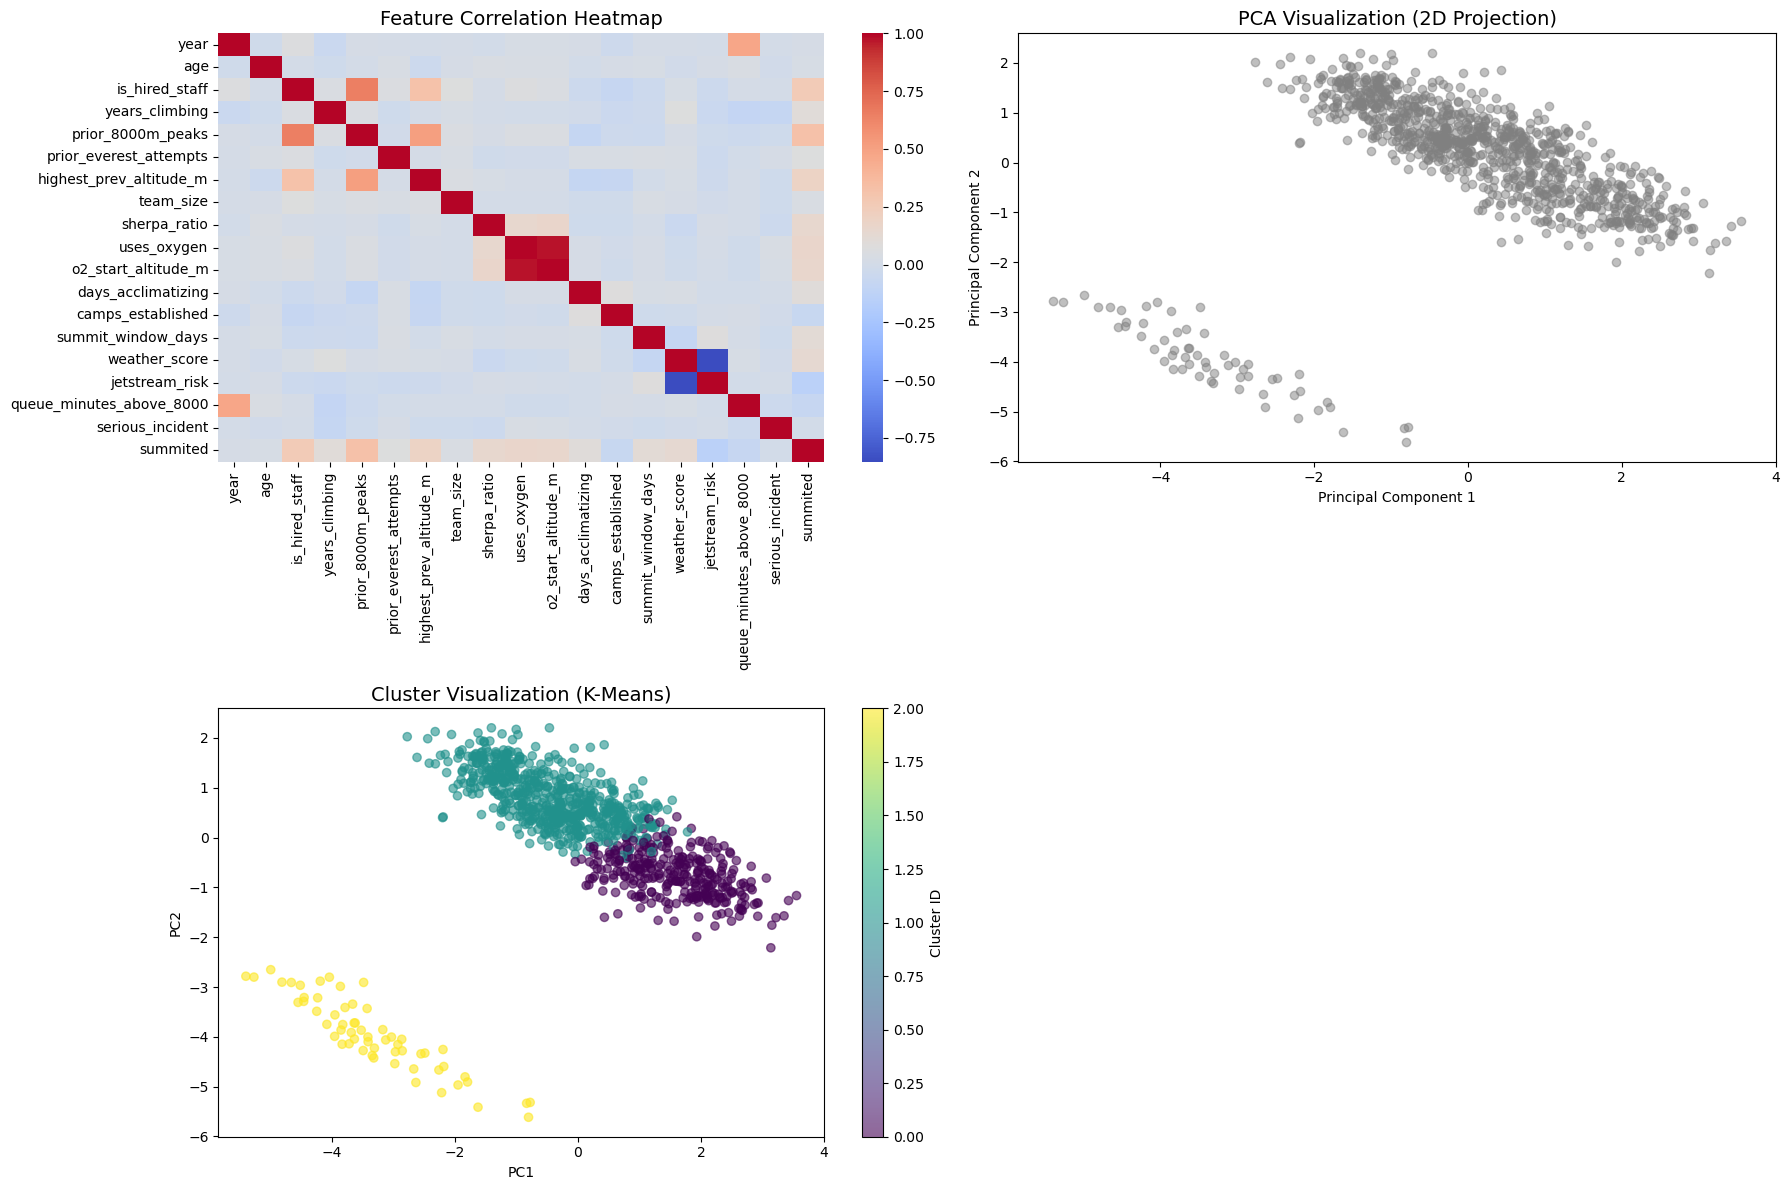

Generating Pairplot (this may take a few seconds)...


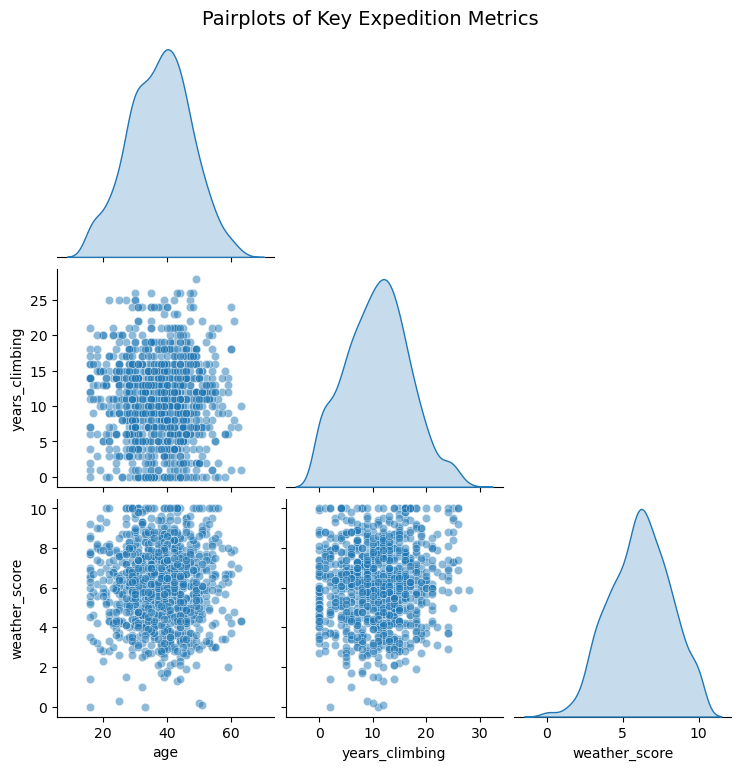

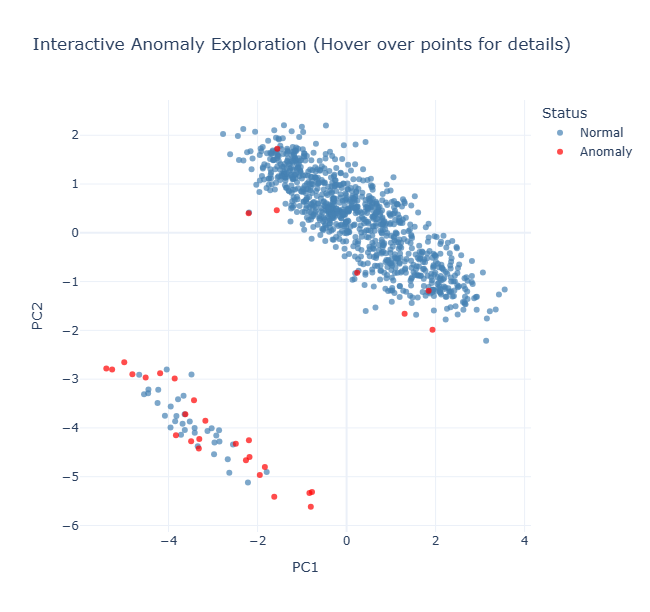

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pandas as pd
import numpy as np

# Align all data to the sample size to prevent length mismatches
if 'SAMPLE_SIZE' in locals() and len(df_clean) > SAMPLE_SIZE:
    dash_df = df_clean.iloc[sample_indices].copy()
    if_preds_dash = if_predictions[sample_indices]
else:
    dash_df = df_clean.copy()
    if_preds_dash = if_predictions

# ---------------------------------------------------------
# Part 1: Static Dashboard (Heatmap, PCA, Clusters)
# ---------------------------------------------------------
fig = plt.figure(figsize=(18, 12))

# 1. Heatmap
ax1 = plt.subplot(2, 2, 1)
sns.heatmap(dash_df.corr(), annot=False, cmap='coolwarm', ax=ax1, cbar=True)
ax1.set_title('Feature Correlation Heatmap', fontsize=14)

# 2. PCA Visualization (Base)
ax2 = plt.subplot(2, 2, 2)
ax2.scatter(X_pca_opt[:, 0], X_pca_opt[:, 1], alpha=0.5, c='gray')
ax2.set_title('PCA Visualization (2D Projection)', fontsize=14)
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')

# 3. Cluster Visualization (Using K-Means results)
ax3 = plt.subplot(2, 2, 3)
scatter = ax3.scatter(X_pca_opt[:, 0], X_pca_opt[:, 1], c=clusters_kmeans, cmap='viridis', alpha=0.6)
ax3.set_title('Cluster Visualization (K-Means)', fontsize=14)
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
plt.colorbar(scatter, ax=ax3, label='Cluster ID')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Part 2: Pairplots
# ---------------------------------------------------------
print("Generating Pairplot (this may take a few seconds)...")
key_features = ['age', 'years_climbing', 'queue_time', 'weather_score']
valid_features = [f for f in key_features if f in dash_df.columns]

sns.pairplot(dash_df[valid_features], diag_kind='kde', corner=True, plot_kws={'alpha': 0.5})
plt.suptitle('Pairplots of Key Expedition Metrics', y=1.02, fontsize=14)
plt.show()

# ---------------------------------------------------------
# Part 3: Interactive Anomaly Exploration
# ---------------------------------------------------------
# Attach PCA coordinates and the properly sized Isolation Forest predictions
dash_df['PC1'] = X_pca_opt[:, 0]
dash_df['PC2'] = X_pca_opt[:, 1]
dash_df['Status'] = ['Anomaly' if x == -1 else 'Normal' for x in if_preds_dash]

# Create interactive scatter plot using Plotly
fig_inter = px.scatter(
    dash_df, 
    x='PC1', 
    y='PC2', 
    color='Status',
    color_discrete_map={'Normal': 'steelblue', 'Anomaly': 'red'},
    hover_data=valid_features,
    title='Interactive Anomaly Exploration (Hover over points for details)',
    opacity=0.7
)

fig_inter.update_layout(height=600, width=900, template="plotly_white")
fig_inter.show()